# Algorithm Performance Analyzer – Searching Algorithms

This notebook analyzes and compares the theoretical and experimental
performance of:

1. Linear Search
2. Iterative Binary Search
3. Recursive Binary Search

The analysis includes best-case, average-case, and worst-case
time complexity, space complexity, execution-time measurements,
CSV storage, and performance graphs.

In [17]:
import time
import random
import csv
import gc
import sys

import matplotlib.pyplot as plt
from IPython.display import Image, display

Matplotlib is building the font cache; this may take a moment.


## 1. Theoretical Complexity Analysis

### Linear Search

- Best Case: O(1)
- Average Case: O(n)
- Worst Case: O(n)
- Space Complexity: O(1)

### Iterative Binary Search

- Best Case: O(1)
- Average Case: O(log n)
- Worst Case: O(log n)
- Space Complexity: O(1)

### Recursive Binary Search

- Best Case: O(1)
- Average Case: O(log n)
- Worst Case: O(log n)
- Space Complexity: O(log n)

In [18]:
def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1

In [19]:
def binary_search_iterative(arr, target):
    low = 0
    high = len(arr) - 1

    while low <= high:
        mid = (low + high) // 2

        if arr[mid] == target:
            return mid

        elif arr[mid] < target:
            low = mid + 1

        else:
            high = mid - 1

    return -1

In [20]:
def binary_search_recursive(arr, target, low, high):
    if low > high:
        return -1

    mid = (low + high) // 2

    if arr[mid] == target:
        return mid

    elif arr[mid] < target:
        return binary_search_recursive(
            arr, target, mid + 1, high
        )

    else:
        return binary_search_recursive(
            arr, target, low, mid - 1
        )

In [21]:
def measure_time(func, arr, target, is_recursive=False, trials=100):

    gc_was_enabled = gc.isenabled()
    gc.disable()

    try:
        times = []

        for _ in range(trials):

            start = time.perf_counter()

            if is_recursive:
                func(arr, target, 0, len(arr) - 1)
            else:
                func(arr, target)

            end = time.perf_counter()

            times.append(end - start)

    finally:
        if gc_was_enabled:
            gc.enable()

    return sum(times) / len(times)

In [22]:
def run_experiment():

    sys.setrecursionlimit(10000)

    input_sizes = [
        100,
        500,
        1000,
        5000,
        10000,
        50000,
        100000,
        500000,
        1000000
    ]

    results = []

    for n in input_sizes:

        arr = list(range(n))

        target = random.choice(arr)

        linear_time = measure_time(
            linear_search,
            arr,
            target
        )

        iterative_time = measure_time(
            binary_search_iterative,
            arr,
            target
        )

        recursive_time = measure_time(
            binary_search_recursive,
            arr,
            target,
            is_recursive=True
        )

        results.append(
            (
                n,
                linear_time,
                iterative_time,
                recursive_time
            )
        )

        print(
            f"n = {n:>8} | "
            f"Linear = {linear_time * 1e6:.3f} us | "
            f"Iterative Binary = {iterative_time * 1e6:.3f} us | "
            f"Recursive Binary = {recursive_time * 1e6:.3f} us"
        )

    return results

In [23]:
results = run_experiment()

n =      100 | Linear = 1.840 us | Iterative Binary = 1.629 us | Recursive Binary = 2.793 us
n =      500 | Linear = 23.830 us | Iterative Binary = 2.756 us | Recursive Binary = 4.207 us
n =     1000 | Linear = 82.054 us | Iterative Binary = 4.179 us | Recursive Binary = 4.339 us
n =     5000 | Linear = 111.564 us | Iterative Binary = 7.525 us | Recursive Binary = 5.137 us
n =    10000 | Linear = 739.177 us | Iterative Binary = 6.122 us | Recursive Binary = 7.734 us
n =    50000 | Linear = 946.347 us | Iterative Binary = 4.259 us | Recursive Binary = 6.185 us
n =   100000 | Linear = 155.573 us | Iterative Binary = 6.592 us | Recursive Binary = 6.359 us
n =   500000 | Linear = 30237.332 us | Iterative Binary = 4.525 us | Recursive Binary = 6.443 us
n =  1000000 | Linear = 59802.897 us | Iterative Binary = 6.457 us | Recursive Binary = 11.842 us


In [24]:
def save_results_csv(
    results,
    filename="searching_results.csv"
):

    with open(filename, "w", newline="") as f:

        writer = csv.writer(f)

        writer.writerow([
            "input_size",
            "linear_search_time_sec",
            "iterative_binary_time_sec",
            "recursive_binary_time_sec"
        ])

        writer.writerows(results)

    print(f"Results saved to {filename}")

In [25]:
save_results_csv(results)

Results saved to searching_results.csv


In [26]:
def plot_results(
    results,
    filename="searching_performance.png"
):

    sizes = [r[0] for r in results]

    linear_times = [
        r[1] * 1e6 for r in results
    ]

    iterative_times = [
        r[2] * 1e6 for r in results
    ]

    recursive_times = [
        r[3] * 1e6 for r in results
    ]

    plt.figure(figsize=(10, 6))

    plt.plot(
        sizes,
        linear_times,
        marker="o",
        label="Linear Search"
    )

    plt.plot(
        sizes,
        iterative_times,
        marker="s",
        label="Iterative Binary Search"
    )

    plt.plot(
        sizes,
        recursive_times,
        marker="^",
        label="Recursive Binary Search"
    )

    plt.xscale("log")

    plt.xlabel("Input Size (n)")
    plt.ylabel("Average Execution Time (microseconds)")

    plt.title(
        "Searching Algorithms - Experimental Performance"
    )

    plt.legend()
    plt.grid(True, which="both", linestyle="--")

    plt.tight_layout()

    plt.savefig(filename, dpi=150)

    plt.show()

    print(f"Graph saved to {filename}")

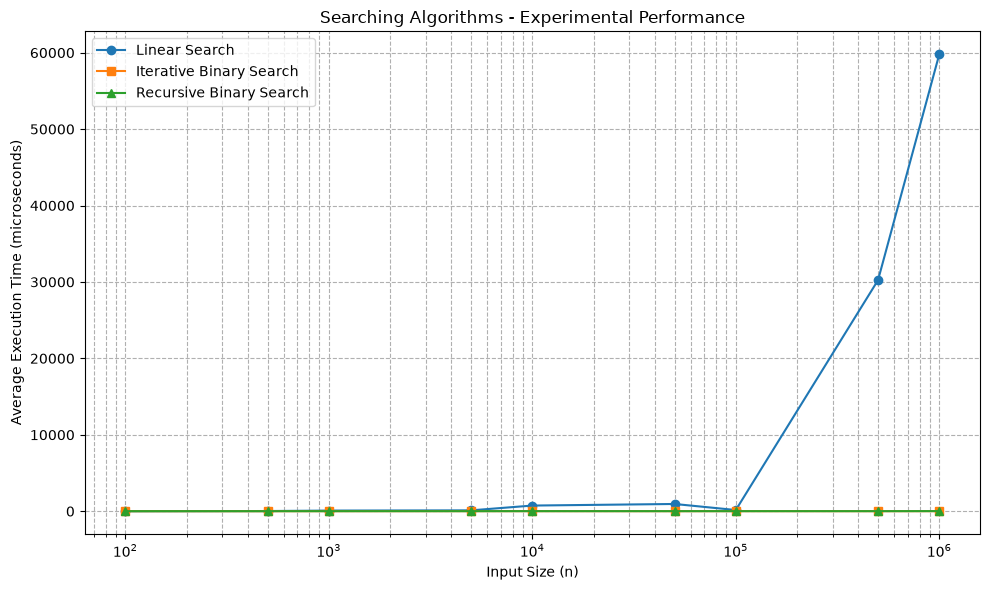

Graph saved to searching_performance.png


In [27]:
plot_results(results)

## 2. Experimental Analysis

The experimental results show how execution time changes as the
input size increases.

### Linear Search

Linear Search generally takes more time as the input size increases.
This agrees with its theoretical average and worst-case complexity
of O(n).

### Iterative Binary Search

Iterative Binary Search grows very slowly with increasing input size.
This agrees with its theoretical complexity of O(log n).

### Recursive Binary Search

Recursive Binary Search also has O(log n) time complexity. However,
it may take slightly more time than iterative binary search because
recursive function calls introduce additional overhead.

### Conclusion

The experimental results generally support the theoretical Big-O
analysis. However, actual execution time can be affected by factors
such as Python interpreter overhead, processor performance, memory,
system load, and measurement noise.